# LLM metrics — poster figures

Two charts for your **ITC poster** from `metrics.jsonl`.

Skips incomplete runs. Uses **successful** generation jobs only.

```bash
pip install pandas matplotlib
```

In [63]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOG_PATH = Path("metrics.jsonl")
if not LOG_PATH.is_file():
    LOG_PATH = Path("data/reviews/metrics.jsonl")

SKIP_RUN_PREFIX = ("e16881e3", "87c6d263", "59c87037")

# --- Poster hardware (edit here or set EVAL_* env vars) ---
POSTER_CPU = os.environ.get("EVAL_CPU", "Intel Core i7-12700KF")
POSTER_RAM_GB = os.environ.get("EVAL_RAM_GB", "64")
POSTER_GPU = os.environ.get("EVAL_GPU", "NVIDIA GeForce RTX 3090 (24 GB VRAM)")
POSTER_LLM = "qwen3:8b"  # poster label (do not use OLLAMA_MODEL env — may be llama3.2:3b in shell)

HARDWARE_LINE = (
    f"Ollama · {POSTER_LLM} · {POSTER_GPU} · {POSTER_CPU} · {POSTER_RAM_GB} GB RAM"
)


def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if not line.startswith("{"):
            line = "{" + line
        rows.append(json.loads(line))
    return pd.DataFrame(rows)


def skipped(run_id: str) -> bool:
    return str(run_id).startswith(SKIP_RUN_PREFIX)


raw = load_jsonl(LOG_PATH)
gens = raw[
    (raw["event"] == "generation")
    & (raw["status"] == "success")
    & raw["seconds_per_question"].notna()
    & ~raw["run_id"].astype(str).apply(skipped)
].copy()
gens["seconds_per_question"] = gens["seconds_per_question"].astype(float)
gens["domain"] = gens["domain"].fillna("")

s = gens["seconds_per_question"]
POSTER_STATS = {
    "n_jobs": len(gens),
    "mean_s": round(s.mean(), 2),
    "median_s": round(s.median(), 2),
    "p95_s": round(s.quantile(0.95), 2),
}

print("Poster hardware:")
print(" ", HARDWARE_LINE)
print(
    f"Jobs: {POSTER_STATS['n_jobs']} | "
    f"mean {POSTER_STATS['mean_s']}s | median {POSTER_STATS['median_s']}s | p95 {POSTER_STATS['p95_s']}s"
)

Poster hardware:
  Ollama · qwen3:8b · NVIDIA GeForce RTX 3090 (24 GB VRAM) · Intel Core i7-12700KF · 64 GB RAM
Jobs: 125 | mean 2.49s | median 2.3s | p95 3.65s


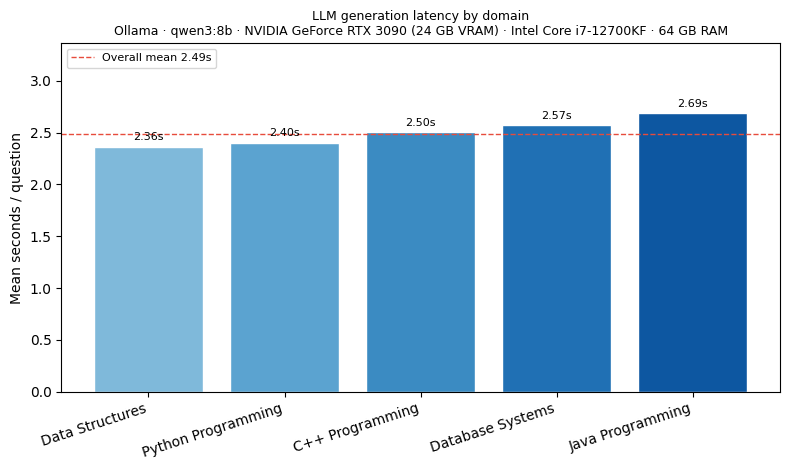

In [64]:
# POSTER FIGURE 1 — Mean latency by domain
by_domain = (
    gens.groupby("domain")["seconds_per_question"]
    .agg(mean_s="mean", n="count")
    .sort_values("mean_s")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = plt.cm.Blues([0.45 + 0.1 * i for i in range(len(by_domain))])
bars = ax.bar(by_domain["domain"], by_domain["mean_s"], color=colors, edgecolor="white")
ax.set_ylabel("Mean seconds / question")
ax.set_title(f"LLM generation latency by domain\n{HARDWARE_LINE}", fontsize=9)
ax.axhline(POSTER_STATS["mean_s"], color="#e74c3c", ls="--", lw=1, label=f"Overall mean {POSTER_STATS['mean_s']}s")
plt.xticks(rotation=18, ha="right")
for b, row in zip(bars, by_domain.itertuples()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.06, f"{row.mean_s:.2f}s", ha="center", fontsize=8)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(0, max(by_domain["mean_s"]) * 1.25)
plt.tight_layout()
plt.savefig("poster_latency_by_domain.png", dpi=200, bbox_inches="tight")
plt.show()

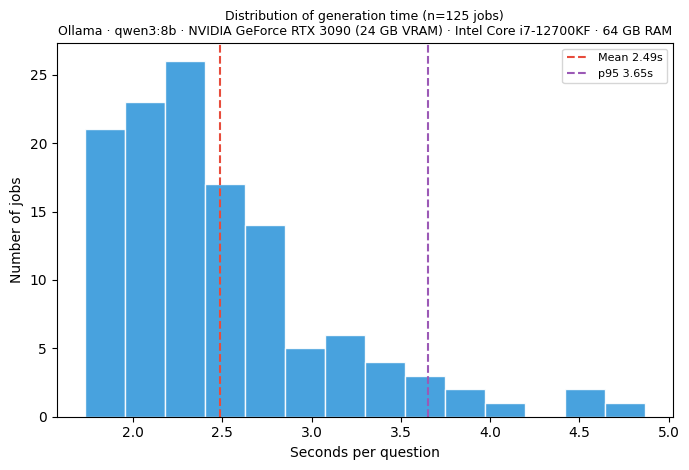

In [65]:
# POSTER FIGURE 2 — Latency distribution
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.hist(gens["seconds_per_question"], bins=14, color="#3498db", edgecolor="white", alpha=0.9)
ax.axvline(POSTER_STATS["mean_s"], color="#e74c3c", ls="--", lw=1.5, label=f"Mean {POSTER_STATS['mean_s']}s")
ax.axvline(POSTER_STATS["p95_s"], color="#9b59b6", ls="--", lw=1.5, label=f"p95 {POSTER_STATS['p95_s']}s")
ax.set_xlabel("Seconds per question")
ax.set_ylabel("Number of jobs")
ax.set_title(
    f"Distribution of generation time (n={POSTER_STATS['n_jobs']} jobs)\n{HARDWARE_LINE}",
    fontsize=9,
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("poster_latency_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

### Poster hardware & latency (copy to slide)

**Experimental setup:** Ollama · **qwen3:8b** · **NVIDIA GeForce RTX 3090 (24 GB)** · **Intel Core i7-12700KF** · **64 GB RAM**

**Generation latency:** mean **2.49 s/question**, p95 **3.65 s** (125 successful jobs, completed batch runs)

**Figure choice:** use **Figure 1** (by domain) on the poster; keep Figure 2 as backup or appendix.